# Dokumentasi Analisis K-Means Clustering


## Dataset Destinasi Wisata Bali

---

## 1. Deskripsi Dataset

Dataset yang digunakan adalah **Bali Destinations** yang memuat informasi destinasi wisata di seluruh kabupaten/kota di Bali.

| Atribut | Nilai |
|---|---|
| Jumlah baris (raw) | 1.443 destinasi |
| Jumlah kolom | 23 kolom |
| Sumber data | Dataset destinasi wisata Bali |
| Cakupan wilayah | 9 kabupaten/kota (Badung, Gianyar, Tabanan, Buleleng, Karangasem, Klungkung, Denpasar, Bangli, Jembrana) |

---

## 2. Preprocessing Data

Sebelum clustering dilakukan, data melalui beberapa tahap pembersihan dan transformasi:

### 2.1 Encoding Variabel Kategorikal
Kolom bertipe teks dikonversi ke numerik menggunakan **Label Encoding** (`sklearn.preprocessing.LabelEncoder`):

| Kolom Asli | Kolom Hasil Encoding |
|---|---|
| `category_main` | `category_main_enc` |
| `sub_category` | `sub_category_enc` |
| `price_level` | `price_level_enc` |
| `regency_city` | `regency_city_enc` |

---

## 3. Variabel yang Digunakan

Sembilan (9) fitur dipilih sebagai input clustering berdasarkan relevansi terhadap karakteristik destinasi wisata:

| No | Variabel | Tipe | Alasan Pemilihan |
|---|---|---|---|
| 1 | `rating` | Numerik | Kualitas/popularitas destinasi dari perspektif pengunjung |
| 2 | `review_count` | Numerik | Tingkat kunjungan dan eksposur destinasi |
| 3 | `estimated_ticket_price` | Numerik | Segmentasi berdasarkan harga akses masuk |
| 4 | `category_main_enc` | Kategorikal (encoded) | Jenis utama destinasi (nature, culture, recreation, general) |
| 5 | `sub_category_enc` | Kategorikal (encoded) | Sub-jenis destinasi (beach, temple, waterfall, dst.) |
| 6 | `price_level_enc` | Kategorikal (encoded) | Level harga (free, low, medium, high) |
| 7 | `data_quality_score` | Numerik | Kelengkapan dan kualitas data destinasi |

---

## 4. Normalisasi Data

Algoritma K-Means sangat sensitif terhadap perbedaan skala antar fitur. Fitur seperti `review_count` (0–101.523) dan `rating` (0–5) berada pada rentang yang sangat berbeda, sehingga normalisasi wajib diterapkan.

**Metode yang digunakan: StandardScaler (Z-Score Normalization)**

---

## 5. Penentuan Nilai K Optimal

Pemilihan jumlah klaster (K) dilakukan menggunakan **empat metode evaluasi** secara bersamaan untuk mendapatkan keputusan yang lebih objektif:

### 5.1 Elbow Method (Inertia / WCSS)
Mengukur total jarak kuadrat setiap titik data ke centroid klasternya (*Within-Cluster Sum of Squares*). Nilai K optimal berada pada titik "siku" kurva di mana penurunan inertia mulai melandai secara signifikan.

### 5.2 Silhouette Score
Mengukur seberapa mirip sebuah objek dengan klasternya sendiri dibandingkan klaster lain. Rentang nilai: **−1 hingga +1**, semakin tinggi semakin baik. K dengan nilai tertinggi menjadi kandidat terbaik.

### 5.3 Davies-Bouldin Index
Mengukur rata-rata kemiripan antar klaster. **Semakin kecil nilainya, semakin baik** — artinya klaster semakin compact dan terpisah satu sama lain.

### 5.4 Calinski-Harabasz Index
Rasio antara dispersi antar klaster dan dispersi dalam klaster. **Semakin besar nilainya, semakin baik** — artinya klaster semakin padat dan terpisah.

### Hasil Evaluasi Pemilihan K (K = 2 hingga K = 11)

| K | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ |
|---|---|---|---|
| 2 | 0.2682 | 1.7381 | 343.99 |
| 3 | 0.3306 | 1.3230 | 377.58 |
| **4** | **0.3622** | **1.1087** | **391.96** |
| 5 | 0.3639 | 1.0269 | 368.59 |
| 6 | 0.3783 | 0.9038 | 430.55 |
| 7 | 0.3944 | 0.8059 | 538.56 |
| 8 | 0.4528 | 0.7345 | 602.91 |
| 9 | 0.4969 | 0.6987 | 670.29 |
| 10 | 0.5203 | 0.7473 | 676.38 |
| 11 | 0.5240 | 0.8201 | 670.29 |

### Keputusan: K = 4

K = 4 dipilih berdasarkan pertimbangan berikut:
- Titik siku (*elbow*) pada kurva inertia terjadi di sekitar K = 4.
- Silhouette Score mencapai **puncak lokal pertama** di K = 4 sebelum turun di K = 5.
- Secara domain knowledge, dataset memiliki **4 kategori utama alami**: `nature`, `culture`, `recreation`, dan `general`.
- K = 4 memberikan keseimbangan terbaik antara kompleksitas model dan interpretabilitas klaster.

---

## 6. Konfigurasi Model K-Means

```python
KMeans(
    n_clusters  = 4,            # Jumlah klaster
    init        = 'k-means++',  # Inisialisasi centroid cerdas (menghindari konvergensi lokal)
    n_init      = 20,           # Dijalankan 20 kali, diambil hasil dengan inertia terkecil
    max_iter    = 300,          # Batas maksimum iterasi per run
    random_state= 42            # Seed untuk reprodusibilitas hasil
)
```

---

## 7. Evaluasi Model Final

| Metrik | Nilai |  
|---|---|
| Inertia (WCSS) | 8.285,23 | 
| Silhouette Score | 0.3622 | 
| Davies-Bouldin Index | 1.1087 | 
| Calinski-Harabasz Score | 391.96 |


---

## 8. Hasil Clustering

### Profil Setiap Klaster

| Klaster | Label | N | Rating | Review (rata-rata) | Harga Tiket (Rp) | % Gratis |
|---|---|---|---|---|---|---|
| 0 | Destinasi Alam & Rekreasi Populer | 465 | 4.50 | 969 | 7.253 | 49,2% |
| 1 | Jasa & Layanan Wisata Lokal | 527 | 4.46 | 561 | 3.872 | 74,2% |
| 2 | Wisata Alam & Budaya Berbayar Murah | 345 | 4.57 | 1.312 | 15.550 | 2,9% |
| 3 | Atraksi & Aktivitas Wisata Premium | 106 | 4.56 | 4.722 | 159.669 | 0,0% |

### Distribusi Kategori per Klaster

| Klaster | culture | general | nature | recreation | Total |
|---|---|---|---|---|---|
| 0 | 2 | 0 | 350 | 113 | 465 |
| 1 | 29 | 498 | 0 | 0 | 527 |
| 2 | 146 | 23 | 164 | 12 | 345 |
| 3 | 4 | 55 | 9 | 38 | 106 |

### Distribusi Price Level per Klaster

| Klaster | free | high | low | medium | Total |
|---|---|---|---|---|---|
| 0 | 229 | 0 | 220 | 16 | 465 |
| 1 | 391 | 0 | 127 | 9 | 527 |
| 2 | 10 | 6 | 295 | 34 | 345 |
| 3 | 0 | 102 | 1 | 3 | 106 |

### Karakteristik Pembeda

### Detail Profil Klaster

* **Klaster 0: Jasa & Layanan Wisata Lokal**
Memiliki *rating* menengah, mayoritas (74%) merupakan destinasi gratis, dan didominasi oleh kategori umum (*general*).
* **Klaster 1: Wisata Alam & Budaya Berbayar Murah**
Menawarkan harga tiket yang rendah, seluruhnya (0% gratis) berbayar, dengan dominasi destinasi bertema budaya (*culture*) dan alam (*nature*).
* **Klaster 2: Destinasi Alam & Rekreasi Populer**
Memiliki jumlah *review* tertinggi kedua dengan variasi *sub-category* yang paling beragam. Didominasi oleh wisata alam (*nature*) dan rekreasi (*recreation*).
* **Klaster 3: Atraksi & Aktivitas Wisata Premium**
Mendapatkan *review* yang sangat tinggi dan 100% berbayar. Harga tiket rata-rata jauh di atas klaster lainnya (Rp159.669) dan didominasi oleh aktivitas premium.



# Setup

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

DATASET_PATH = ROOT / "data" / "final" / "bali_destinations.csv"
RESULT_PATH = ROOT / "data" / "clustered" / "bali_destination.csv"

# Konfigurasi tampilan
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

# Load Dataset

In [36]:
df = pd.read_csv(DATASET_PATH)

print("=" * 50)
print("INFORMASI UMUM DATASET")
print("=" * 50)
print(f"Jumlah baris   : {df.shape[0]}")
print(f"Jumlah kolom   : {df.shape[1]}")
print(f"\nDaftar kolom   :")
for col in df.columns:
    print(f"  - {col} ({df[col].dtype})")

print("\n--- 5 Data Pertama ---")
df.head()

INFORMASI UMUM DATASET
Jumlah baris   : 1443
Jumlah kolom   : 27

Daftar kolom   :
  - destination_id (str)
  - name (str)
  - category_raw (str)
  - category_main (str)
  - detail_category (float64)
  - sub_category (str)
  - description (float64)
  - tags (float64)
  - activity (float64)
  - regency_city (str)
  - district (str)
  - estimated_ticket_price (int64)
  - is_free (bool)
  - price_level (str)
  - rating (float64)
  - review_count (int64)
  - latitude (float64)
  - longitude (float64)
  - maps_url (str)
  - image_url (str)
  - has_coordinates (bool)
  - has_description (bool)
  - data_quality_score (float64)
  - content_text (str)
  - popularity_score (float64)
  - budget_tiers (str)
  - recommendation_eligible (bool)

--- 5 Data Pertama ---


,destination_id,name,category_raw,category_main,detail_category,sub_category,description,tags,activity,regency_city,...,longitude,maps_url,image_url,has_coordinates,has_description,data_quality_score,content_text,popularity_score,budget_tiers,recommendation_eligible
0,DEST-001,Patung Titi Banda,Umum,general,NaN,landmark,NaN,NaN,NaN,Denpasar,...,115.255043,https://www.google.com/maps/place/Patung+Titi+...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,True,False,0.65,patung titi banda general landmark denpasar de...,0.656787,"low,medium,high",True
1,DEST-002,Uma.palak.(parkir.2),Rekreasi,recreation,NaN,landmark,NaN,NaN,NaN,Denpasar,...,115.212975,https://www.google.com/maps/place/Uma.palak.%2...,https://lh3.googleusercontent.com/p/AF1QipOS1G...,True,False,0.70,uma palak recreation landmark denpasar denpasa...,0.401062,"low,medium,high",True
2,DEST-003,Tukad Bindu Park,Rekreasi,recreation,NaN,landmark,NaN,NaN,NaN,Denpasar,...,115.235812,https://www.google.com/maps/place/Tukad+Bindu+...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,True,False,0.80,tukad bindu park recreation landmark denpasar ...,0.600304,"low,medium,high",True
3,DEST-004,Pantai Padang Galak,Alam,nature,NaN,beach,NaN,NaN,NaN,Denpasar,...,115.263301,https://www.google.com/maps/place/Pantai+Padan...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,True,False,0.80,pantai padang galak nature beach denpasar denp...,0.536801,"low,medium,high",True
4,DEST-005,Museum Le Mayeur,Budaya,culture,NaN,museum,NaN,NaN,NaN,Denpasar,...,115.263678,https://www.google.com/maps/place/Museum+Le+Ma...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,True,False,0.80,museum le mayeur culture museum denpasar denpa...,0.504263,"low,medium,high",True


# Feature Engineering

In [37]:
# Encoding kolom kategorikal dengan Label Encoding
le_category   = LabelEncoder()
le_subcategory = LabelEncoder()
le_price_level = LabelEncoder()
le_regency     = LabelEncoder()

df['category_main_enc']  = le_category.fit_transform(df['category_main'])
df['sub_category_enc']   = le_subcategory.fit_transform(df['sub_category'])
df['price_level_enc']    = le_price_level.fit_transform(df['price_level'])
df['regency_city_enc']   = le_regency.fit_transform(df['regency_city'])

print("\nMapping category_main  :", dict(zip(le_category.classes_, le_category.transform(le_category.classes_))))
print("Mapping price_level    :", dict(zip(le_price_level.classes_, le_price_level.transform(le_price_level.classes_))))

# Pilih fitur untuk clustering
features = [
    'rating',
    'review_count',
    'estimated_ticket_price',
    'category_main_enc',
    'sub_category_enc',
    'price_level_enc',
    'data_quality_score'
]

X = df[features].copy()
print(f"\nJumlah fitur untuk clustering : {X.shape[1]}")
print(f"Jumlah sampel                 : {X.shape[0]}")
print("\nFitur yang digunakan:")
for f in features:
    print(f"  - {f}")


Mapping category_main  : {'culture': np.int64(0), 'general': np.int64(1), 'nature': np.int64(2), 'recreation': np.int64(3)}
Mapping price_level    : {'free': np.int64(0), 'high': np.int64(1), 'low': np.int64(2), 'medium': np.int64(3)}

Jumlah fitur untuk clustering : 7
Jumlah sampel                 : 1443

Fitur yang digunakan:
  - rating
  - review_count
  - estimated_ticket_price
  - category_main_enc
  - sub_category_enc
  - price_level_enc
  - data_quality_score


# Normalization

In [38]:
# Menggunakan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Determination of Optimal K Value

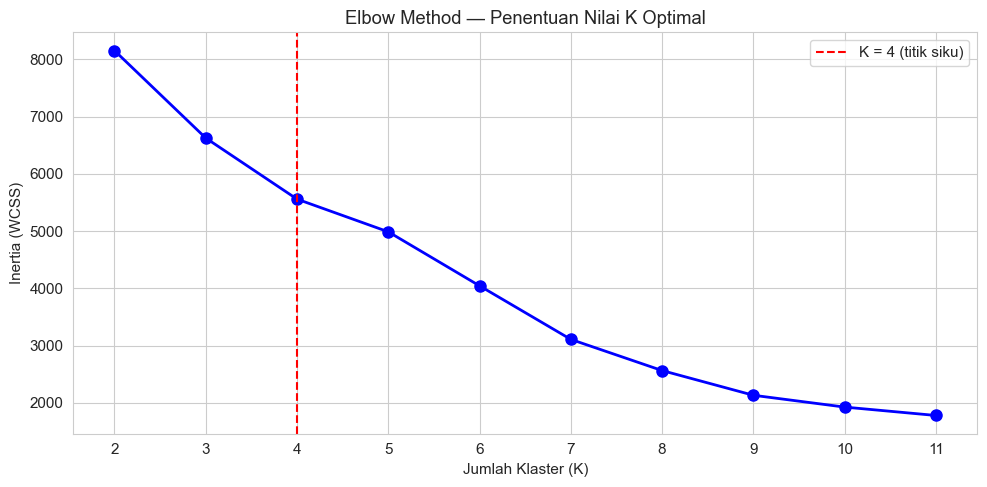

Plot disimpan: elbow_method.png


In [39]:
# ============================================================
# METODE 1: ELBOW METHOD (Inertia / WCSS)
# ============================================================


k_range = range(2, 12)
inertia_list = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertia_list.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia_list, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method — Penentuan Nilai K Optimal')
plt.xticks(k_range)
plt.axvline(x=4, color='red', linestyle='--', label='K = 4 (titik siku)')
plt.legend()
plt.tight_layout()
plt.show()
print("Plot disimpan: elbow_method.png")

K =  2 | Silhouette Score = 0.2682
K =  3 | Silhouette Score = 0.3306
K =  4 | Silhouette Score = 0.3622
K =  5 | Silhouette Score = 0.3639
K =  6 | Silhouette Score = 0.3783
K =  7 | Silhouette Score = 0.3944
K =  8 | Silhouette Score = 0.4528
K =  9 | Silhouette Score = 0.4969
K = 10 | Silhouette Score = 0.5203
K = 11 | Silhouette Score = 0.5240


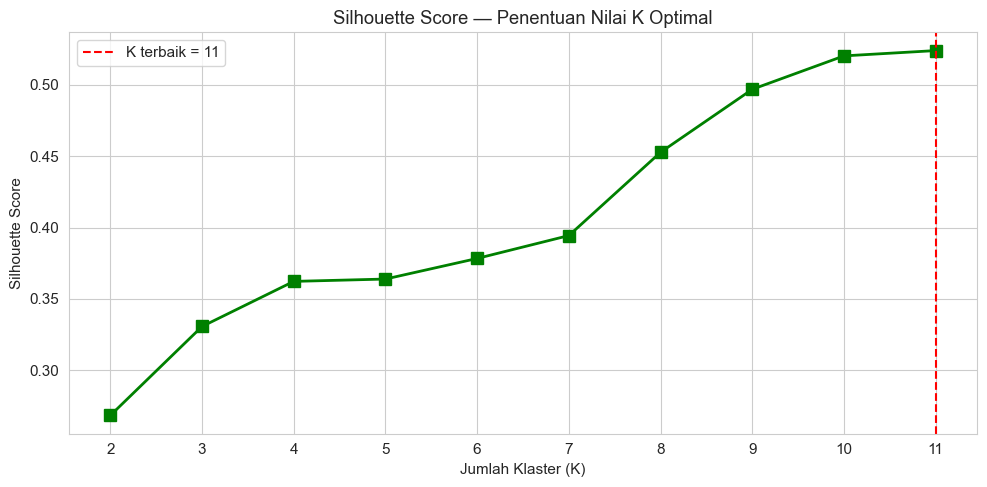


K dengan Silhouette Score tertinggi: 11


In [40]:
# ============================================================
# METODE 2: SILHOUETTE SCORE
# ============================================================

silhouette_list = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels, sample_size=500, random_state=42)
    silhouette_list.append(score)
    print(f"K = {k:2d} | Silhouette Score = {score:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_list, 'gs-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Penentuan Nilai K Optimal')
plt.xticks(k_range)
best_k_sil = k_range[np.argmax(silhouette_list)]
plt.axvline(x=best_k_sil, color='red', linestyle='--', label=f'K terbaik = {best_k_sil}')
plt.legend()
plt.tight_layout()
plt.show()
print(f"\nK dengan Silhouette Score tertinggi: {best_k_sil}")

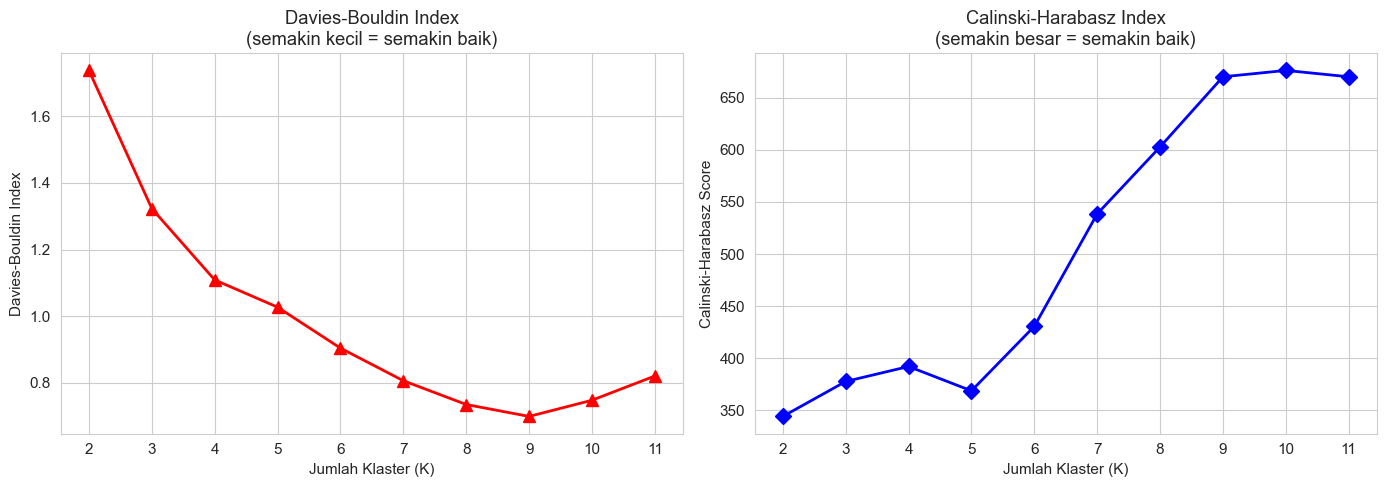


Ringkasan Evaluasi Pemilihan K:
   K |   Silhouette |  Davies-Bouldin |  Calinski-Harabasz
---------------------------------------------------------
   2 |       0.2682 |          1.7381 |             343.99
   3 |       0.3306 |          1.3230 |             377.58
   4 |       0.3622 |          1.1087 |             391.96
   5 |       0.3639 |          1.0269 |             368.59
   6 |       0.3783 |          0.9038 |             430.55
   7 |       0.3944 |          0.8059 |             538.56
   8 |       0.4528 |          0.7345 |             602.91
   9 |       0.4969 |          0.6987 |             670.29
  10 |       0.5203 |          0.7473 |             676.38
  11 |       0.5240 |          0.8201 |             670.29


In [41]:
# ============================================================
# METODE 3: DAVIES-BOULDIN INDEX & CALINSKI-HARABASZ INDEX
# ============================================================

db_list = []
ch_list = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    db_list.append(davies_bouldin_score(X_scaled, labels))
    ch_list.append(calinski_harabasz_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, db_list, 'r^-', linewidth=2, markersize=8)
axes[0].set_xlabel('Jumlah Klaster (K)')
axes[0].set_ylabel('Davies-Bouldin Index')
axes[0].set_title('Davies-Bouldin Index\n(semakin kecil = semakin baik)')
axes[0].set_xticks(k_range)

axes[1].plot(k_range, ch_list, 'bD-', linewidth=2, markersize=8)
axes[1].set_xlabel('Jumlah Klaster (K)')
axes[1].set_ylabel('Calinski-Harabasz Score')
axes[1].set_title('Calinski-Harabasz Index\n(semakin besar = semakin baik)')
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.show()

print("\nRingkasan Evaluasi Pemilihan K:")
print(f"{'K':>4} | {'Silhouette':>12} | {'Davies-Bouldin':>15} | {'Calinski-Harabasz':>18}")
print("-" * 57)
for i, k in enumerate(k_range):
    print(f"{k:>4} | {silhouette_list[i]:>12.4f} | {db_list[i]:>15.4f} | {ch_list[i]:>18.2f}")

### Berdasarkan analisis Elbow Method, Silhouette Score, Davies-Bouldin, dan Calinski-Harabasz, dipilih K = 4 karena mencerminkan 4 kategori utama destinasi Bali dan menunjukkan keseimbangan terbaik antar metrik evaluasi.

# Training K-Means Model

In [42]:
K_OPTIMAL = 4

kmeans_final = KMeans(
    n_clusters=K_OPTIMAL,
    init='k-means++',   
    n_init=20,          
    max_iter=300,       
    random_state=42     
)

kmeans_final.fit(X_scaled)
df['cluster'] = kmeans_final.labels_

print("=" * 50)
print(f"Model K-Means selesai dilatih dengan K = {K_OPTIMAL}")
print(f"Inertia Final  : {kmeans_final.inertia_:.2f}")
print(f"Jumlah iterasi : {kmeans_final.n_iter_}")
print("\nDistribusi anggota per klaster:")
print(df['cluster'].value_counts().sort_index().rename(lambda x: f"Klaster {x}"))

Model K-Means selesai dilatih dengan K = 4
Inertia Final  : 5556.96
Jumlah iterasi : 5

Distribusi anggota per klaster:
cluster
Klaster 0    465
Klaster 1    527
Klaster 2    345
Klaster 3    106
Name: count, dtype: int64


# Model Evaluation

In [43]:
labels_final = kmeans_final.labels_

sil_final = silhouette_score(X_scaled, labels_final, sample_size=500, random_state=42)
db_final  = davies_bouldin_score(X_scaled, labels_final)
ch_final  = calinski_harabasz_score(X_scaled, labels_final)

print("=" * 50)
print("EVALUASI MODEL K-MEANS FINAL (K = 4)")
print("=" * 50)
print(f"Silhouette Score        : {sil_final:.4f}  (range -1 hingga 1, semakin tinggi semakin baik)")
print(f"Davies-Bouldin Index    : {db_final:.4f}  (semakin kecil semakin baik)")
print(f"Calinski-Harabasz Score : {ch_final:.2f} (semakin besar semakin baik)")
print(f"Inertia (WCSS)          : {kmeans_final.inertia_:.2f}")

EVALUASI MODEL K-MEANS FINAL (K = 4)
Silhouette Score        : 0.3589  (range -1 hingga 1, semakin tinggi semakin baik)
Davies-Bouldin Index    : 1.1224  (semakin kecil semakin baik)
Calinski-Harabasz Score : 392.23 (semakin besar semakin baik)
Inertia (WCSS)          : 5556.96


# Interpretation Clustering Result

In [44]:
# ============================================================
# ANALISIS PROFIL KLASTER
# ============================================================

print("=" * 60)
print("PROFIL STATISTIK PER KLASTER")
print("=" * 60)

cluster_profile = df.groupby('cluster').agg(
    jumlah_destinasi     = ('name', 'count'),
    rating_rata2         = ('rating', 'mean'),
    rating_median        = ('rating', 'median'),
    review_count_rata2   = ('review_count', 'mean'),
    harga_tiket_rata2    = ('estimated_ticket_price', 'mean'),
    gratis_persen        = ('is_free', lambda x: round(x.mean() * 100, 1)),
    lat_rata2            = ('latitude', 'mean'),
    lon_rata2            = ('longitude', 'mean'),
).round(2)

print(cluster_profile.to_string())

PROFIL STATISTIK PER KLASTER
         jumlah_destinasi  rating_rata2  rating_median  review_count_rata2  harga_tiket_rata2  gratis_persen  lat_rata2  lon_rata2
cluster                                                                                                                           
0                     465          4.50            4.5              969.19            7253.76           49.2      -8.48     115.24
1                     527          4.46            4.6              560.97            3872.87           74.2      -8.46     115.20
2                     345          4.57            4.6             1312.91           15550.72            2.9      -8.43     115.21
3                     106          4.56            4.6             4722.58          159669.81            0.0      -8.48     115.26


In [45]:
# ============================================================
# DISTRIBUSI KATEGORI PER KLASTER
# ============================================================

print("\n=== Distribusi Category Main per Klaster ===\n")
cat_dist = pd.crosstab(
    df['cluster'],
    df['category_main'],
    margins=True
)
print(cat_dist)

print("\n=== Distribusi Price Level per Klaster ===\n")
price_dist = pd.crosstab(
    df['cluster'],
    df['price_level'],
    margins=True
)
print(price_dist)


=== Distribusi Category Main per Klaster ===

category_main  culture  general  nature  recreation   All
cluster                                                  
0                    2        0     350         113   465
1                   29      498       0           0   527
2                  146       23     164          12   345
3                    4       55       9          38   106
All                181      576     523         163  1443

=== Distribusi Price Level per Klaster ===

price_level  free  high  low  medium   All
cluster                                   
0             229     0  220      16   465
1             391     0  127       9   527
2              10     6  295      34   345
3               0   102    1       3   106
All           630   108  643      62  1443


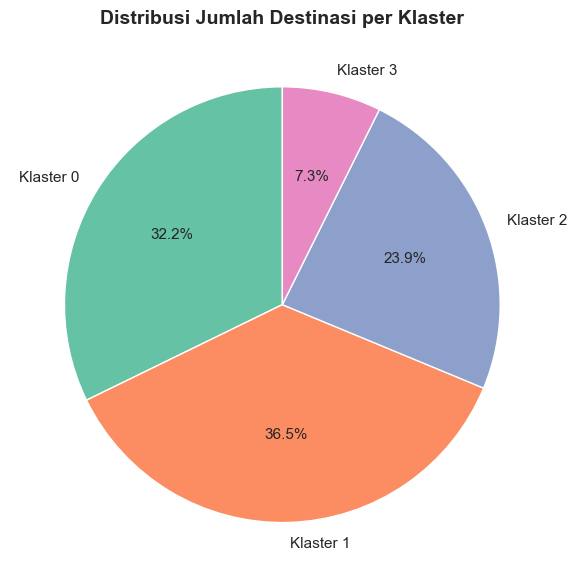

In [46]:
# ============================================================
# VISUALISASI 1: DISTRIBUSI KLASTER (PIE CHART)
# ============================================================

cluster_counts = df['cluster'].value_counts().sort_index()
labels_pie = [f'Klaster {i}' for i in cluster_counts.index]

plt.figure(figsize=(8, 6))
plt.pie(cluster_counts, labels=labels_pie, autopct='%1.1f%%',
        startangle=90, colors=sns.color_palette('Set2', K_OPTIMAL))
plt.title('Distribusi Jumlah Destinasi per Klaster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Variansi yang dijelaskan oleh PC1: 24.8%
Variansi yang dijelaskan oleh PC2: 19.1%
Total variansi 2 komponen pertama : 43.9%


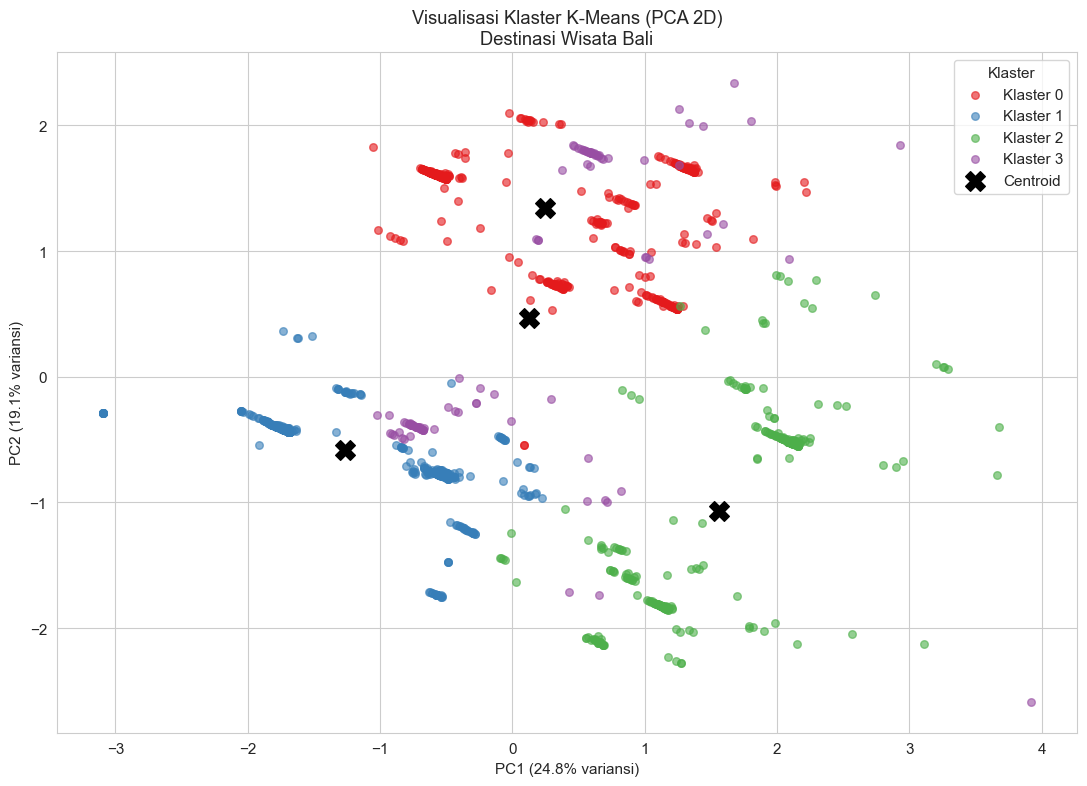

In [47]:
# ============================================================
# VISUALISASI 2: PCA 2D — VISUALISASI KLASTER DALAM 2 DIMENSI
# ============================================================
# Karena clustering dilakukan dalam 9 dimensi, PCA digunakan
# untuk memproyeksikan data ke 2D untuk tujuan visualisasi.

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variansi yang dijelaskan oleh PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variansi yang dijelaskan oleh PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variansi 2 komponen pertama : {sum(pca.explained_variance_ratio_)*100:.1f}%")

plt.figure(figsize=(11, 8))
colors = sns.color_palette('Set1', K_OPTIMAL)

for cluster_id in sorted(df['cluster'].unique()):
    mask = df['cluster'].values == cluster_id
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f'Klaster {cluster_id}',
        alpha=0.6,
        s=30,
        color=colors[cluster_id]
    )

# Centroid di ruang PCA
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c='black', marker='X', s=200, zorder=5, label='Centroid'
)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variansi)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variansi)')
plt.title('Visualisasi Klaster K-Means (PCA 2D)\nDestinasi Wisata Bali')
plt.legend(title='Klaster')
plt.tight_layout()
plt.show()

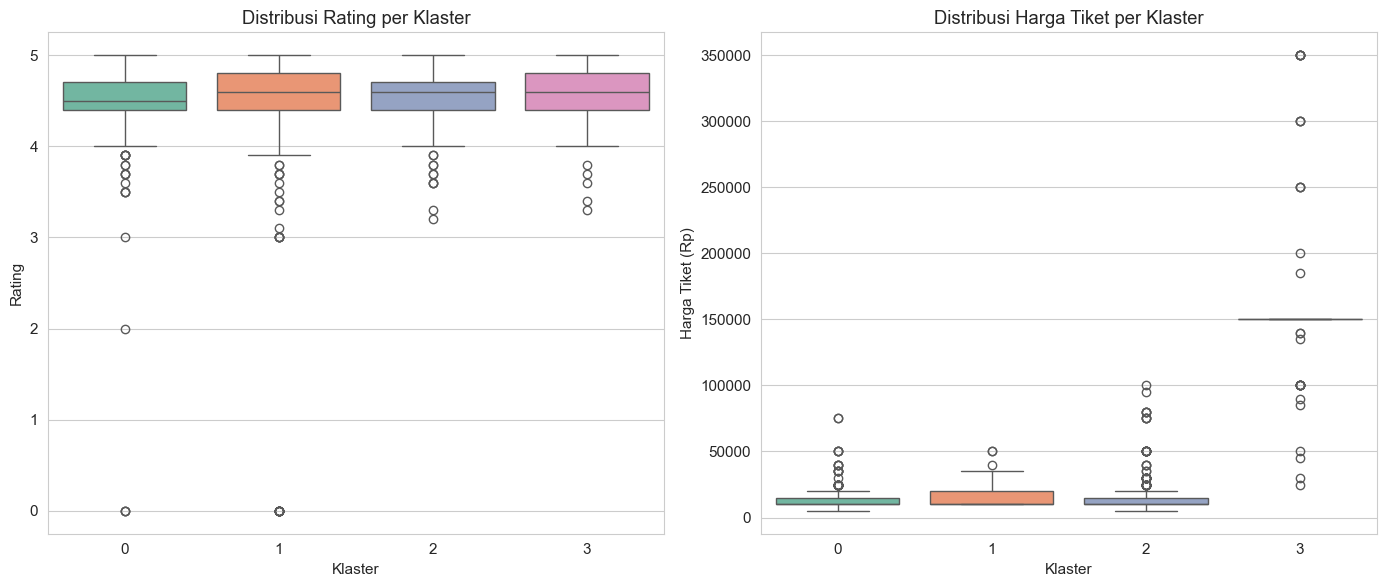

In [48]:
# ============================================================
# VISUALISASI 3: BOXPLOT RATING & HARGA PER KLASTER
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='cluster', y='rating',
            palette='Set2', ax=axes[0])
axes[0].set_title('Distribusi Rating per Klaster')
axes[0].set_xlabel('Klaster')
axes[0].set_ylabel('Rating')

sns.boxplot(data=df[df['estimated_ticket_price'] > 0],
            x='cluster', y='estimated_ticket_price',
            palette='Set2', ax=axes[1])
axes[1].set_title('Distribusi Harga Tiket per Klaster')
axes[1].set_xlabel('Klaster')
axes[1].set_ylabel('Harga Tiket (Rp)')

plt.tight_layout()
plt.show()

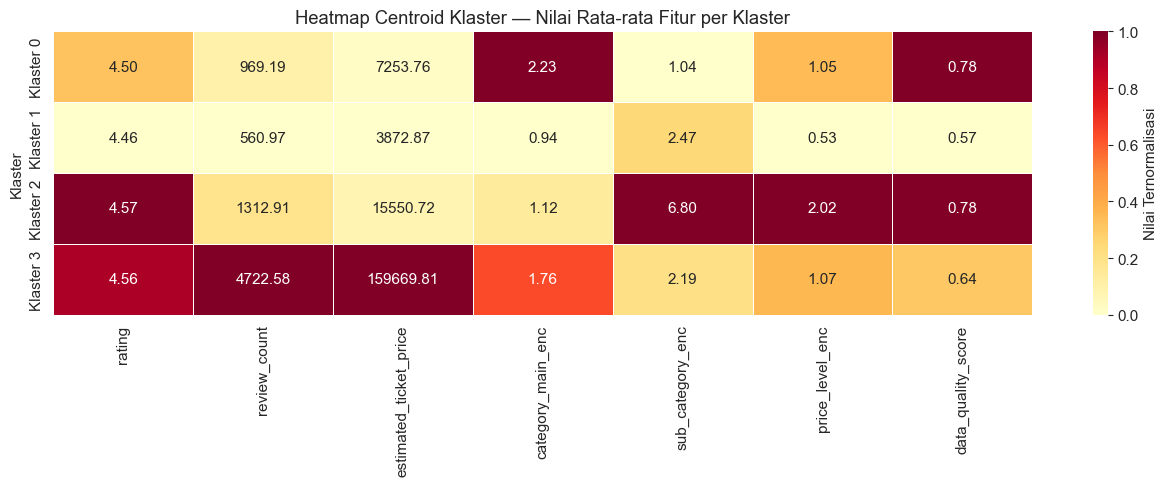

In [49]:
# ============================================================
# VISUALISASI 4: HEATMAP CENTROID (FITUR PER KLASTER)
# ============================================================

centroid_df = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=features
)
centroid_df.index = [f'Klaster {i}' for i in range(K_OPTIMAL)]

# Normalisasi per kolom untuk heatmap yang lebih informatif
centroid_norm = (centroid_df - centroid_df.min()) / (centroid_df.max() - centroid_df.min())

plt.figure(figsize=(13, 5))
sns.heatmap(
    centroid_norm,
    annot=centroid_df.round(2),
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Nilai Ternormalisasi'}
)
plt.title('Heatmap Centroid Klaster — Nilai Rata-rata Fitur per Klaster')
plt.ylabel('Klaster')
plt.tight_layout()
plt.show()

In [50]:
# ============================================================
# INTERPRETASI & PENAMAAN KLASTER
# ============================================================
cluster_labels = {
    0: 'Jasa & Layanan Wisata Lokal',
    1: 'Wisata Alam & Budaya Berbayar Murah',
    2: 'Destinasi Alam & Rekreasi Populer',
    3: 'Atraksi & Aktivitas Wisata Premium',
}

df['cluster_label'] = df['cluster'].map(cluster_labels)

print("=== Distribusi Klaster dengan Label ===")
print(df['cluster_label'].value_counts())

=== Distribusi Klaster dengan Label ===
cluster_label
Wisata Alam & Budaya Berbayar Murah    527
Jasa & Layanan Wisata Lokal            465
Destinasi Alam & Rekreasi Populer      345
Atraksi & Aktivitas Wisata Premium     106
Name: count, dtype: int64


# Export Clustering Result

In [51]:
df.to_csv(RESULT_PATH, index=False)